In [22]:
!pip install biopython networkx scipy pandas numpy matplotlib infomap scikit-learn seaborn 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


from Bio.PDB import PDBParser
from scipy.spatial import cKDTree
from collections import Counter

In [24]:
nome_proteina = "1A3N"
PDB_FILES = ["data/raw/1A3N/1A3N.pdb"]

In [25]:
AA_CLASS = {

    # Hidrofóbicos
    "ALA":"hydrophobic",
    "VAL":"hydrophobic",
    "ILE":"hydrophobic",
    "LEU":"hydrophobic",
    "MET":"hydrophobic",
    "PHE":"hydrophobic",
    "TRP":"hydrophobic",
    "PRO":"hydrophobic",

    # Polares
    "SER":"polar",
    "THR":"polar",
    "ASN":"polar",
    "GLN":"polar",
    "TYR":"polar",
    "CYS":"polar",

    # Positivos
    "LYS":"positive",
    "ARG":"positive",
    "HIS":"positive",

    # Negativos
    "ASP":"negative",
    "GLU":"negative",

    # Glicina
    "GLY":"special"
}

In [26]:
def biochemical_similarity(res1, res2):

    c1 = AA_CLASS.get(res1, "other")
    c2 = AA_CLASS.get(res2, "other")

    if c1 == c2:
        return 1.0

    # atração eletrostática
    if (
        (c1 == "positive" and c2 == "negative")
        or
        (c1 == "negative" and c2 == "positive")
    ):
        return 0.9

    # polar-polar
    if (
        c1 == "polar"
        and
        c2 == "polar"
    ):
        return 0.8

    # hidrofóbico-polar
    if (
        c1 == "hydrophobic"
        and
        c2 == "polar"
    ) or (
        c2 == "hydrophobic"
        and
        c1 == "polar"
    ):
        return 0.3

    return 0.5

In [27]:
def load_residues(pdb_files):
    parser = PDBParser(QUIET=True)
    residues = []
    for pdb_file in pdb_files:
        structure = parser.get_structure(nome_proteina, pdb_file)
        for model in structure:
            for chain in model:
                for residue in chain:
                    if residue.id[0] != " ":
                        continue
                    if "CA" not in residue:
                        continue
                    ca = residue["CA"]
                    residues.append({
                        "node_id":
                        f"{chain.id}_{residue.id[1]}",
                        "chain":
                        chain.id,
                        "resname":
                        residue.resname,
                        "resid":
                        residue.id[1],
                        "x":
                        float(ca.coord[0]),
                        "y":
                        float(ca.coord[1]),
                        "z":
                        float(ca.coord[2])
                    })
    return pd.DataFrame(residues)

In [28]:
res_df = load_residues(PDB_FILES)
print("Resíduos:", len(res_df))
res_df.head()

Resíduos: 572


,node_id,chain,resname,resid,x,y,z
0,A_1,A,VAL,1,10.228,20.761000,6.807
1,A_2,A,LEU,2,6.624,21.451000,7.763
2,A_3,A,SER,3,4.831,23.237000,4.928
3,A_4,A,PRO,4,2.252,25.966000,5.311
4,A_5,A,ALA,5,-0.457,23.367001,4.513


In [29]:
chain_sequences = (
    res_df
    .sort_values(
        ["chain", "resid"]
    )
    .groupby("chain")["resname"]
    .apply(list)
)
chain_sequences.head()

chain
A    [VAL, LEU, SER, PRO, ALA, ASP, LYS, THR, ASN, ...
B    [HIS, LEU, THR, PRO, GLU, GLU, LYS, SER, ALA, ...
C    [VAL, LEU, SER, PRO, ALA, ASP, LYS, THR, ASN, ...
D    [HIS, LEU, THR, PRO, GLU, GLU, LYS, SER, ALA, ...
Name: resname, dtype: object

In [30]:
AA3_TO_1 = {
    "ALA":"A",
    "ARG":"R",
    "ASN":"N",
    "ASP":"D",
    "CYS":"C",
    "GLN":"Q",
    "GLU":"E",
    "GLY":"G",
    "HIS":"H",
    "ILE":"I",
    "LEU":"L",
    "LYS":"K",
    "MET":"M",
    "PHE":"F",
    "PRO":"P",
    "SER":"S",
    "THR":"T",
    "TRP":"W",
    "TYR":"Y",
    "VAL":"V"
}

chain_sequences = {}

for chain, group in res_df.groupby("chain"):

    sequence = "".join(
        AA3_TO_1.get(
            aa,
            "X"
        )
        for aa in group
            .sort_values("resid")
            ["resname"]
    )

    chain_sequences[chain] = sequence

print(chain_sequences)
for chain, seq in chain_sequences.items():

    print(
        chain,
        len(seq)
    )

{'A': 'VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR', 'B': 'HLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH', 'C': 'VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR', 'D': 'HLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH'}
A 141
B 145
C 141
D 145


In [31]:
# Similaridade LCS
def lcs_identity(seq_a, seq_b):

    if len(seq_a) < len(seq_b):
        seq_a, seq_b = seq_b, seq_a

    dp = [0]*(len(seq_b)+1)

    for aa in seq_a:

        prev = 0

        for j, bb in enumerate(seq_b, start=1):

            tmp = dp[j]

            if aa == bb:

                dp[j] = prev + 1

            else:

                dp[j] = max(
                    dp[j],
                    dp[j-1]
                )

            prev = tmp

    return dp[-1] / max(
        len(seq_a),
        len(seq_b)
    )

In [32]:
# Construir chain_similarity

from itertools import combinations

chain_similarity = {}

for c1, c2 in combinations(
    chain_sequences.keys(),
    2
):

    sim = lcs_identity(
        chain_sequences[c1],
        chain_sequences[c2]
    )

    key = tuple(
        sorted((c1,c2))
    )

    chain_similarity[key] = sim

# Similaridade própria
for c in chain_sequences:

    chain_similarity[(c,c)] = 1.0

In [33]:
# Converter para matriz
chains = sorted(chain_sequences.keys())
chain_matrix = pd.DataFrame(
    index=chains,
    columns=chains,
    dtype=float
)

for c1 in chains:
    for c2 in chains:
        key = tuple(sorted((c1,c2)))
        chain_matrix.loc[c1,c2] = chain_similarity[key]
chain_matrix.round(2)

,A,B,C,D
A,1.00,0.48,1.00,0.48
B,0.48,1.00,0.48,1.00
C,1.00,0.48,1.00,0.48
D,0.48,1.00,0.48,1.00


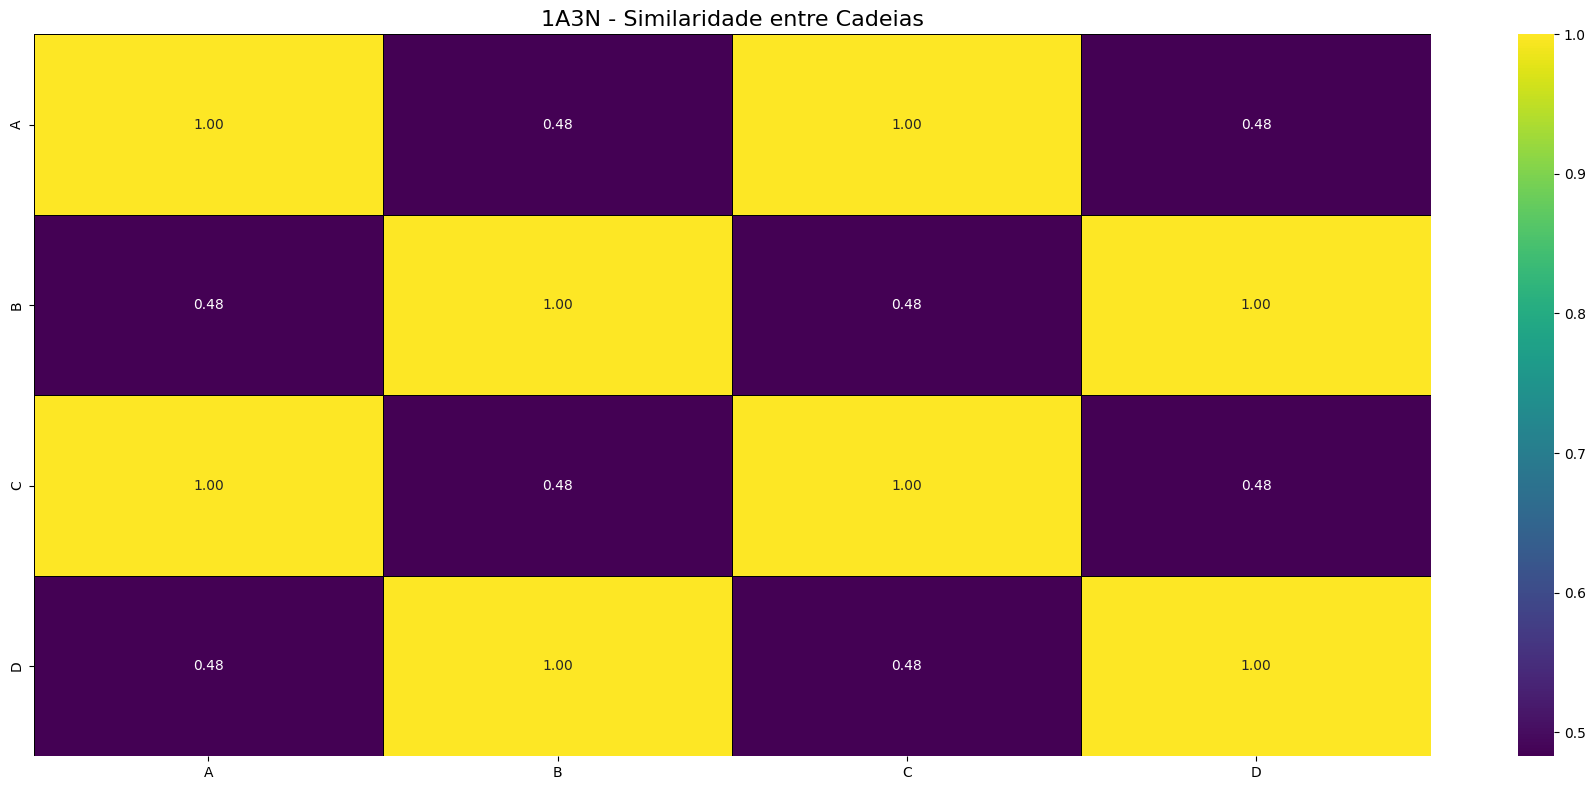

In [34]:
plt.figure(figsize=(18, 8))
sns.heatmap(
    chain_matrix,
    cmap="viridis",
    annot=True, fmt=".2f",  # Adiciona anotações com 2 casas decimais
    linewidths=.5, linecolor="black" # Adiciona linhas para melhor separação
)

plt.title(nome_proteina+" - Similaridade entre Cadeias", fontsize=16)
plt.tight_layout()
plt.show()

In [35]:
def build_chain_sim_graph(residues_df, chain_similarity, cutoff, homology_threshold):
    G = nx.Graph()
    # ------------------------------------------------------------------
    # Nós
    # ------------------------------------------------------------------
    for row in residues_df.itertuples():

        G.add_node(
            row.node_id,
            chain=row.chain,
            residue=row.resname,
            resid=row.resid,
            x=row.x,
            y=row.y,
            z=row.z
        )
    coords = residues_df[
        ["x", "y", "z"]
    ].values

    node_ids = residues_df["node_id"].values
    residues = residues_df["resname"].values
    chains = residues_df["chain"].values
    resids = residues_df["resid"].values

    # ------------------------------------------------------------------
    # Índice auxiliar:
    # (cadeia, resid) -> índice
    # ------------------------------------------------------------------
    residue_index = {}
    for idx in range(len(residues_df)):

        residue_index[
            (chains[idx], resids[idx])
        ] = idx

    # ------------------------------------------------------------------
    # ETAPA 1
    # Contatos espaciais
    # ------------------------------------------------------------------

    tree = cKDTree(coords)
    spatial_pairs = tree.query_pairs(r=cutoff)
    for i, j in spatial_pairs:
        distance = np.linalg.norm(
            coords[i] - coords[j]
        )
        spatial_weight = np.exp(
            -distance / cutoff
        )
        bio_weight = biochemical_similarity(
            residues[i],
            residues[j]
        )
        chain_a = chains[i]
        chain_b = chains[j]
        chain_key = tuple(
            sorted((chain_a, chain_b))
        )
        chain_weight = chain_similarity.get(
            chain_key,
            0.0
        )
        final_weight = (
            spatial_weight
            * (1 + bio_weight)
            * (1 + chain_weight)
        )

        G.add_edge(
            node_ids[i],
            node_ids[j],
            edge_type="spatial",
            distance=distance,
            spatial_weight=spatial_weight,
            bio_weight=bio_weight,
            chain_weight=chain_weight,
            weight=final_weight
        )

    # ------------------------------------------------------------------
    # ETAPA 2
    # Ligações por homologia entre cadeias
    # ------------------------------------------------------------------

    for (c1, c2), sim in chain_similarity.items():
        if c1 == c2:
            continue
        if sim < homology_threshold:
            continue
        chain1 = residues_df[
            residues_df["chain"] == c1
        ]
        chain2 = residues_df[
            residues_df["chain"] == c2
        ]
        common_resids = set(
            chain1["resid"]
        ).intersection(
            set(chain2["resid"])
        )
        for resid in common_resids:
            idx1 = residue_index.get(
                (c1, resid)
            )
            idx2 = residue_index.get(
                (c2, resid)
            )
            if idx1 is None or idx2 is None:
                continue
            node1 = node_ids[idx1]
            node2 = node_ids[idx2]
            homology_weight = sim
            if G.has_edge(node1, node2):

                G[node1][node2]["weight"] += homology_weight
                G[node1][node2]["edge_type"] = "mixed"
            else:
                G.add_edge(
                    node1,
                    node2,
                    edge_type="homology",
                    spatial_weight=0.0,
                    bio_weight=0.0,
                    chain_weight=sim,
                    weight=homology_weight
                )
    return G

In [36]:
# Distância máxima para considerar uma interação (Angstroms)
cutoff=4.0
# Similaridade entre as cadeias para considerar uma interação
homology_threshold=0.95

G = build_chain_sim_graph(res_df, chain_similarity, cutoff, homology_threshold)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

# Listar os nós com atributos
nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
display(nodes_df.head())

# Listar as arestas com atributos
edges_df = pd.DataFrame([
    {"source": u, "target": v, **d}
    for u, v, d in G.edges(data=True)
])
display(edges_df.head())

Nós: 572
Arestas: 859


,chain,residue,resid,x,y,z
A_1,A,VAL,1,10.228,20.761000,6.807
A_2,A,LEU,2,6.624,21.451000,7.763
A_3,A,SER,3,4.831,23.237000,4.928
A_4,A,PRO,4,2.252,25.966000,5.311
A_5,A,ALA,5,-0.457,23.367001,4.513


,source,target,edge_type,distance,spatial_weight,bio_weight,chain_weight,weight
0,A_1,A_2,spatial,3.791945,0.387521,1.0,1.0,1.550082
1,A_1,C_1,homology,NaN,0.000000,0.0,1.0,1.000000
2,A_2,A_3,spatial,3.800246,0.386717,0.3,1.0,1.005465
3,A_2,C_2,homology,NaN,0.000000,0.0,1.0,1.000000
4,A_3,A_4,spatial,3.774304,0.389233,0.3,1.0,1.012007


In [37]:
same_chain = 0
different_chain = 0

for _, _, d in G.edges(data=True):

    if d["chain_weight"] > 0.95:
        same_chain += 1
    else:
        different_chain += 1

print("Alta similaridade:", same_chain)
print("Baixa similaridade:", different_chain)

Alta similaridade: 859
Baixa similaridade: 0


In [38]:
degrees = [d for _,d in G.degree()]

print("="*60)
print("Grau médio:", np.mean(degrees))
print("Grau máximo:", np.max(degrees))
print("Densidade:", nx.density(G))
print(f"Conectividade: {nx.is_connected(G)}")
if nx.is_connected(G):
    print(f"Comprimento médio dos caminhos mais curtos: {nx.average_shortest_path_length(G):.2f}")
    print(f"Diâmetro: {nx.diameter(G)}")
print("="*60)

Grau médio: 3.0034965034965033
Grau máximo: 5
Densidade: 0.00526006392906568
Conectividade: False


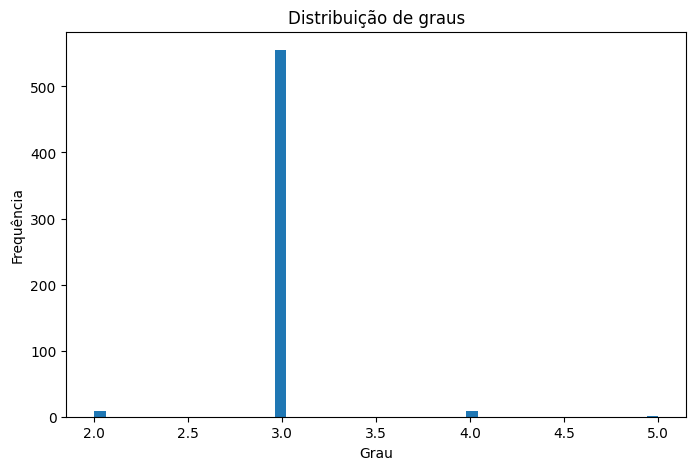

In [39]:
plt.figure(figsize=(8,5))
plt.hist(degrees, bins=50)
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de graus")
plt.show()

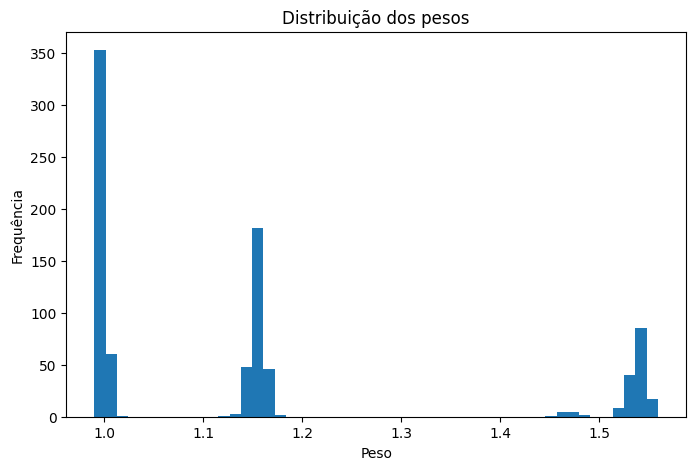

In [40]:
weights = [
    G[u][v]["weight"]
    for u,v in G.edges()
]

plt.figure(figsize=(8,5))

plt.hist(
    weights,
    bins=50
)

plt.xlabel("Peso")
plt.ylabel("Frequência")
plt.title("Distribuição dos pesos")

plt.show()

In [41]:
chain_counts = Counter(
    nx.get_node_attributes(
        G,
        "chain"
    ).values()
)

pd.DataFrame(
    chain_counts.items(),
    columns=["Chain","Residues"]
).sort_values("Chain")

,Chain,Residues
0,A,141
1,B,145
2,C,141
3,D,145


In [42]:
# Dados dos nós
degrees = dict(G.degree())
print("Degree Centrality: OK")
clustering = nx.clustering(G)
print("Clustering Centrality: OK")
closeness = nx.closeness_centrality(G)
print("Closeness Centrality: OK")
betweenness = nx.betweenness_centrality(G)
print("Betwenness  Centrality: OK")
#eigenvector = nx.eigenvector_centrality(G)
eigenvector = nx.eigenvector_centrality_numpy(G)
print("Eigenvetor Centrality: OK")
page_rank = nx.pagerank(G)
print("Pagerank Centrality: OK")

df_nos = pd.DataFrame({
    "node_id": list(G.nodes()),
    "grau": [degrees[n] for n in G.nodes()],
    "clustering": [clustering[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "page_rank": [page_rank[n] for n in G.nodes()]
})


Degree Centrality: OK
Clustering Centrality: OK
Closeness Centrality: OK
Betwenness  Centrality: OK


AmbiguousSolution: `eigenvector_centrality_numpy` does not give consistent results for disconnected graphs

In [ ]:
df_nos.to_csv("outputs/"+nome_proteina+"_"+str(cutoff)+"_centralidades_nos.csv", index=False)

In [ ]:
print("Estatísticas dos primeiros nós:")
print(df_nos.head().to_string(index=False))
print("="*60)
print("Dados das primeiras arestas:")
for u, v, data in list(G.edges(data=True))[:10]:
    print(f"{u}-{v} {data}")
print("="*60)

In [ ]:
metricas = ["grau", "clustering", "closeness", "betweenness", "eigenvector", "page_rank"]
# Criar DataFrame com estatísticas descritivas lado a lado
df_stats = pd.DataFrame({m: df_nos[m].describe() for m in metricas})

print("="*60)
print("Estatísticas comparativas das métricas de centralidade")
display(df_stats)
print("="*60)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    axes[i].hist(df_nos[metric], bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
plt.suptitle(nome_proteina+"_"+str(cutoff)+" - Métricas de centralidade (todos os vértices)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlação entre todas as métricas
corr = df_nos[metricas].corr()
display(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title(nome_proteina+"_"+str(cutoff)+" - Correlação entre métricas de centralidade (todos os vértices)")
plt.show()



In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    valores = df_nos[metric]
    
    # Histograma
    counts, bins, _ = axes[i].hist(valores, bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
    # Escala log-log
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    
    # Linha característica (ajuste linear em log-log)
    mask = (counts > 0) & (bins[:-1] > 0)  # filtrar valores válidos
    x = bins[:-1][mask]
    y = counts[mask]
    
    if len(x) > 2:  # só ajusta se houver pontos suficientes
        logx = np.log10(x)
        logy = np.log10(y)
        
        try:
            coef = np.polyfit(logx, logy, 1)  # ajuste linear em log-log
            fitted = 10**(coef[1]) * x**coef[0]
            axes[i].plot(x, fitted, "r--", label=f"linha característica (α={coef[0]:.2f})")
            axes[i].legend(fontsize=8)
        except np.linalg.LinAlgError:
            # Se o ajuste não convergir, apenas pula
            pass


plt.suptitle(nome_proteina+"_"+str(cutoff)+" - Métricas de centralidade (escala log-log)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
graus = df_nos["grau"]

# Normalização dos valores de grau
norm = plt.Normalize(vmin=graus.min(), vmax=graus.max())

# Cores baseadas no grau
cores = plt.cm.viridis(norm(graus))

# Tamanho proporcional ao grau
node_sizes = [300 + g*30 for g in graus] 

# Criar dicionário de posições para o layout
pos = {}
for _, linha in res_df.iterrows():
    pos[linha["node_id"]] = (
        linha["x"],
        linha["y"]
    )

plt.figure(figsize=(12,10))
ax = plt.gca()

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=ax
)

plt.title(nome_proteina+"_"+str(cutoff)+" - Grau dos nós (cor e tamanho)")

# Barra de cores para interpretação
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ax=ax,
    label="Grau do nó",
    shrink=0.7,
    aspect=30,
    orientation="horizontal"
)

plt.show()


In [ ]:
from scipy.sparse import csgraph

A = nx.to_numpy_array(G, weight="weight")
print(A.shape)

L = csgraph.laplacian(A, normed=False)
print(L.shape)

L_norm = csgraph.laplacian(A, normed=True)
print(L_norm.shape)

In [ ]:
from scipy.sparse.linalg import eigsh

eigenvalues, eigenvectors = eigsh(
    L_norm,
    k=10,
    which="SM"
)

print(eigenvalues)

In [ ]:
# Espectro da Laplaciana
plt.plot(sorted(eigenvalues), 'o-')
plt.title(nome_proteina+"_"+str(cutoff)+" - Espectro da Laplaciana")
plt.xlabel("Índice")
plt.ylabel("Autovalor")
plt.show()

# Subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Histograma dos Autovalores ---
axes[0].hist(eigenvalues, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title(nome_proteina+"_"+str(cutoff)+" - Histograma dos Autovalores")
axes[0].set_xlabel("Autovalor")
axes[0].set_ylabel("Frequência")

# --- Histograma dos Autovalores em escala log-log ---
axes[1].hist(eigenvalues, bins=30, color="salmon", edgecolor="black")
axes[1].set_title(nome_proteina+"_"+str(cutoff)+" - Histograma (log-log)")
axes[1].set_xlabel("Autovalor")
axes[1].set_ylabel("Frequência")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


In [ ]:
fiedler = eigenvectors[:,1]
plt.figure(figsize=(8,4))

plt.hist(
    fiedler,
    bins=100
)

plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")

plt.title("Distribuição do vetor de Fiedler")

plt.show()

In [ ]:
nodes = list(G.nodes())

spectral_partition = pd.DataFrame({

    "node_id": nodes,

    "spectral_group":
    (fiedler > 0).astype(int)

})

spectral_partition.head()

In [ ]:
spectral_partition[
    "spectral_group"
].value_counts()

In [ ]:
nodes = pd.DataFrame({

    "node_id": list(G.nodes()),

    "chain": [
        G.nodes[n]["chain"]
        for n in G.nodes()
    ],

    "spectral_group":
    (fiedler > 0).astype(int)
})

pd.crosstab(
    nodes["chain"],
    nodes["spectral_group"]
)

In [ ]:
print("Vetor de Fiedler:")
print(np.round(fiedler,4))

# Histograma da distribuição dos valores do vetor de Fiedler
plt.figure(figsize=(8,6))
plt.hist(fiedler, bins=30, color="skyblue", edgecolor="black")
plt.title(nome_proteina+"_"+str(cutoff)+" - Distribuição do Vetor de Fiedler")
plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")
plt.show()


colors = ['red' if v>0 else 'blue' for v in fiedler]
nx.draw(G,
        pos=pos,
        node_size=node_sizes,
        node_color=colors,
        with_labels=False,
        font_size=7,
        edge_color="lightgray",
        alpha=0.9,
        )
plt.title(nome_proteina+"_"+str(cutoff)+" - Separação pelo vetor de Fiedler")
plt.show()

In [ ]:
import plotly.graph_objects as go
import networkx as nx

# ==========================================================
# Coordenadas dos nós
# ==========================================================
node_x = []
node_y = []
node_z = []
colors = []
hover_text = []

for i, node in enumerate(G.nodes()):
    node_x.append(G.nodes[node]["x"])
    node_y.append(G.nodes[node]["y"])
    node_z.append(G.nodes[node]["z"])

    # Cor baseada no vetor de Fiedler (positivo = vermelho, negativo = azul)
    colors.append("red" if fiedler[i] > 0 else "blue")

    hover_text.append(
        f"Node: {node}<br>"
        f"Chain: {G.nodes[node]['chain']}<br>"
        f"Resid: {G.nodes[node]['resid']}<br>"
        f"Fiedler: {fiedler[i]:.4f}"
    )

# ==========================================================
# Figura 3D única
# ==========================================================
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=node_x,
        y=node_y,
        z=node_z,
        mode="markers",
        marker=dict(
            size=4,
            color=colors,
            opacity=0.85,
            line=dict(width=0.1, color="black")
        ),
        text=hover_text,
        hoverinfo="text"
    )
)

# ==========================================================
# Layout
# ==========================================================
fig.update_layout(
    title=nome_proteina+"_"+str(cutoff)+" - Separação pelo vetor de Fiedler",
    width=900,
    height=700,
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ordena os valores do vetor de Fiedler
sorted_indices = np.argsort(fiedler)
sorted_values = fiedler[sorted_indices]

# Scatterplot 2D
plt.figure(figsize=(10,6))
plt.scatter(range(len(sorted_values)), sorted_values,
            c=["red" if v > 0 else "blue" for v in sorted_values],
            alpha=0.7, edgecolor="black", s=30)

plt.axhline(0, color="black", linestyle="--", linewidth=1)  # linha de separação
plt.title(nome_proteina + " - Scatterplot do vetor de Fiedler")
plt.xlabel("Nós (ordenados)")
plt.ylabel("Valor do vetor de Fiedler")
plt.show()


In [ ]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import modularity

louvain_comms = louvain_communities(
    G,
    weight="weight",
    seed=42
)

print("Comunidades:", len(louvain_comms))

Q_louvain = modularity(
    G,
    louvain_comms,
    weight="weight"
)

print("Modularidade:", Q_louvain)

In [ ]:
louvain_membership = {}

for cid, community in enumerate(louvain_comms):

    for node in community:

        louvain_membership[node] = cid

louvain_df = pd.DataFrame({

    "node_id":
    list(louvain_membership.keys()),

    "louvain":
    list(louvain_membership.values())
})

louvain_df.head()

In [ ]:
pd.Series(
    louvain_membership
).value_counts().sort_values(
    ascending=False
).head(20)

In [ ]:
from infomap import Infomap

im = Infomap()

node_to_int = {
    node:i
    for i,node in enumerate(G.nodes())
}

int_to_node = {
    i:node
    for node,i in node_to_int.items()
}

for u,v,data in G.edges(data=True):

    im.add_link(
        node_to_int[u],
        node_to_int[v],
        float(data["weight"])
    )

im.run()

print(
    "Comunidades:",
    im.num_top_modules
)

In [ ]:
infomap_membership = {}

for node in im.nodes:

    infomap_membership[
        int_to_node[node.node_id]
    ] = node.module_id

infomap_df = pd.DataFrame({

    "node_id":
    list(infomap_membership.keys()),

    "infomap":
    list(infomap_membership.values())
})

pd.Series(
    infomap_membership
).value_counts().sort_values(
    ascending=False
).head(20)

In [ ]:
truth = {}

for node in G.nodes():

    chain = G.nodes[node]["chain"]

    if chain in list("AC"):
        truth[node] = "Alpha"

    elif chain in list("BD"):
        truth[node] = "Beta"


In [ ]:
truth_df = pd.DataFrame({

    "node_id":
    list(truth.keys()),

    "truth":
    list(truth.values())
})

truth_df.head()

In [ ]:
eval_louvain = truth_df.merge(
    louvain_df,
    on="node_id"
)

eval_louvain.head()

In [ ]:
eval_infomap = truth_df.merge(
    infomap_df,
    on="node_id"
)

eval_infomap.head()

In [ ]:
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score
)

nmi_louvain = normalized_mutual_info_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

ari_louvain = adjusted_rand_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print("NMI Louvain =", nmi_louvain)
print("ARI Louvain =", ari_louvain)

nmi_infomap = normalized_mutual_info_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

ari_infomap = adjusted_rand_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print("NMI Infomap =", nmi_infomap)
print("ARI Infomap =", ari_infomap)

In [ ]:
import numpy as np
from sklearn.metrics.cluster import contingency_matrix

def purity_score(
    y_true,
    y_pred
):

    cm = contingency_matrix(
        y_true,
        y_pred
    )

    return np.sum(
        np.max(cm, axis=0)
    ) / np.sum(cm)

purity_louvain = purity_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print(
    "Purity Louvain =",
    purity_louvain
)

purity_infomap = purity_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print(
    "Purity Infomap =",
    purity_infomap
)

In [ ]:
louvain_vs_truth = pd.crosstab(
    eval_louvain["truth"],
    eval_louvain["louvain"]
)
louvain_vs_truth.style.background_gradient(
    cmap="Blues"
)

In [ ]:
infomap_vs_truth = pd.crosstab(
    eval_infomap["truth"],
    eval_infomap["infomap"]
)

infomap_vs_truth.style.background_gradient(
    cmap="Blues"
)

In [ ]:
louvain_chain_comm_df = pd.DataFrame({

    "node_id": list(louvain_membership.keys()),

    "community": list(louvain_membership.values()),

    "chain": [
        G.nodes[node]["chain"]
        for node in louvain_membership.keys()
    ]
})

louvain_chain_vs_comm = pd.crosstab(
    louvain_chain_comm_df["chain"],
    louvain_chain_comm_df["community"]
)

louvain_chain_vs_comm.style.background_gradient(
    cmap="Blues"
)

In [ ]:
infomap_chain_comm_df = pd.DataFrame({

    "node_id": list(infomap_membership.keys()),

    "community": list(infomap_membership.values()),

    "chain": [
        G.nodes[node]["chain"]
        for node in infomap_membership.keys()
    ]
})

infomap_chain_vs_comm = pd.crosstab(
    infomap_chain_comm_df["chain"],
    infomap_chain_comm_df["community"]
)

infomap_chain_vs_comm.style.background_gradient(
    cmap="Blues"
)

In [ ]:
louvain_dominant_comm = louvain_chain_vs_comm.idxmax(axis=1)
louvain_dominant_comm

In [ ]:
infomap_dominant_comm = infomap_chain_vs_comm.idxmax(axis=1)
infomap_dominant_comm

In [ ]:
louvain_dominant_count = louvain_chain_vs_comm.max(axis=1)

pd.DataFrame({
    "community": louvain_dominant_comm,
    "residues": louvain_dominant_count
})

In [ ]:
infomap_dominant_count = infomap_chain_vs_comm.max(axis=1)

pd.DataFrame({
    "community": infomap_dominant_comm,
    "residues": infomap_dominant_count
})

In [ ]:
louvain_chain_purity = (
    louvain_chain_vs_comm.max(axis=1)
    /
    louvain_chain_vs_comm.sum(axis=1)
)

louvain_chain_purity.sort_values(
    ascending=False
)

In [ ]:
infomap_chain_purity = (
    infomap_chain_vs_comm.max(axis=1)
    /
    infomap_chain_vs_comm.sum(axis=1)
)

infomap_chain_purity.sort_values(
    ascending=False
)

In [ ]:
plt.figure(figsize=(12,8))

plt.imshow(
    louvain_chain_vs_comm,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(louvain_chain_vs_comm.shape[1]),
    louvain_chain_vs_comm.columns,
    rotation=90
)

plt.yticks(
    range(louvain_chain_vs_comm.shape[0]),
    louvain_chain_vs_comm.index
)

plt.xlabel("Comunidade Louvain")
plt.ylabel("Cadeia")

plt.title(nome_proteina+"_"+str(cutoff)+" - Cadeia × Comunidade")

plt.show()

In [ ]:
plt.figure(figsize=(12,8))

plt.imshow(
    infomap_chain_vs_comm,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(infomap_chain_vs_comm.shape[1]),
    infomap_chain_vs_comm.columns,
    rotation=90
)

plt.yticks(
    range(infomap_chain_vs_comm.shape[0]),
    infomap_chain_vs_comm.index
)

plt.xlabel("Comunidade Infomap")
plt.ylabel("Cadeia")

plt.title(nome_proteina+"_"+str(cutoff)+" - Cadeia × Comunidade")

plt.show()

In [ ]:
import plotly.graph_objects as go

# coordenadas dos nós
node_x = []
node_y = []
node_z = []

for node in G.nodes():

    node_x.append(G.nodes[node]["x"])
    node_y.append(G.nodes[node]["y"])
    node_z.append(G.nodes[node]["z"])

# arestas
edge_x = []
edge_y = []
edge_z = []

for u, v in G.edges():

    edge_x.extend([
        G.nodes[u]["x"],
        G.nodes[v]["x"],
        None
    ])

    edge_y.extend([
        G.nodes[u]["y"],
        G.nodes[v]["y"],
        None
    ])

    edge_z.extend([
        G.nodes[u]["z"],
        G.nodes[v]["z"],
        None
    ])

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode="lines",
    line=dict(width=1),
    hoverinfo="none"
)

node_trace = go.Scatter3d(
    x=node_x,
    y=node_y,
    z=node_z,
    mode="markers",
    marker=dict(
        size=2
    )
)

fig = go.Figure(
    data=[
        edge_trace,
        node_trace
    ]
)

fig.update_layout(
    title=nome_proteina+"_"+str(cutoff)+" - Rede da proteína",
    showlegend=False
)

fig.show()

In [ ]:
chain_to_id = {
    c:i
    for i,c in enumerate(
        sorted(
            set(
                nx.get_node_attributes(
                    G,
                    "chain"
                ).values()
            )
        )
    )
}

node_color = [

    chain_to_id[
        G.nodes[node]["chain"]
    ]

    for node in G.nodes()
]

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import networkx as nx

# ==========================================================
# Mapeamento das cadeias para cores
# ==========================================================

all_chains = sorted(
    set(
        nx.get_node_attributes(
            G,
            "chain"
        ).values()
    )
)

chain_to_id = {
    chain:i
    for i,chain in enumerate(all_chains)
}

# ==========================================================
# Coordenadas
# ==========================================================

node_x = []
node_y = []
node_z = []

chain_colors = []
community_colors = []

hover_text = []

for node in G.nodes():

    node_x.append(
        G.nodes[node]["x"]
    )

    node_y.append(
        G.nodes[node]["y"]
    )

    node_z.append(
        G.nodes[node]["z"]
    )

    chain_colors.append(
        chain_to_id[
            G.nodes[node]["chain"]
        ]
    )

    community_colors.append(
        louvain_membership[node]
    )

    hover_text.append(
        f"Node: {node}<br>"
        f"Chain: {G.nodes[node]['chain']}<br>"
        f"Resid: {G.nodes[node]['resid']}"
    )

# ==========================================================
# Figura com 2 cenas 3D
# ==========================================================

fig = make_subplots(
    rows=1,
    cols=2,

    specs=[
        [
            {"type":"scene"},
            {"type":"scene"}
        ]
    ],

    subplot_titles=(
        "Colorido por Cadeia",
        "Colorido por Comunidade Louvain"
    )
)

# ==========================================================
# Cadeias
# ==========================================================

fig.add_trace(

    go.Scatter3d(

        x=node_x,
        y=node_y,
        z=node_z,

        mode="markers",

        marker=dict(

            size=3,

            color=chain_colors,

            colorscale="Turbo",

            opacity=0.85,

            colorbar=dict(
                title="Chain",
                x=0.45
            )
        ),

        text=hover_text,

        hoverinfo="text"

    ),

    row=1,
    col=1
)

# ==========================================================
# Comunidades Louvain
# ==========================================================

fig.add_trace(

    go.Scatter3d(

        x=node_x,
        y=node_y,
        z=node_z,

        mode="markers",

        marker=dict(

            size=3,

            color=community_colors,

            colorscale="Viridis",

            opacity=0.85,

            colorbar=dict(
                title="Community",
                x=1.02
            )
        ),

        text=hover_text,

        hoverinfo="text"

    ),

    row=1,
    col=2
)

# ==========================================================
# Layout
# ==========================================================

fig.update_layout(

    title=(nome_proteina+"_"+str(cutoff)+" - Comparação "
        "Cadeias vs Comunidades Louvain"
    ),

    width=1800,
    height=900,

    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),

    scene2=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()

In [ ]:
# ==========================================================
# Mapeamento das cadeias para cores
# ==========================================================

all_chains = sorted(
    set(
        nx.get_node_attributes(
            G,
            "chain"
        ).values()
    )
)

chain_to_id = {
    chain:i
    for i,chain in enumerate(all_chains)
}

# ==========================================================
# Coordenadas
# ==========================================================

node_x = []
node_y = []
node_z = []

chain_colors = []
community_colors = []

hover_text = []

for node in G.nodes():

    node_x.append(
        G.nodes[node]["x"]
    )

    node_y.append(
        G.nodes[node]["y"]
    )

    node_z.append(
        G.nodes[node]["z"]
    )

    chain_colors.append(
        chain_to_id[
            G.nodes[node]["chain"]
        ]
    )

    community_colors.append(
        infomap_membership[node]
    )

    hover_text.append(
        f"Node: {node}<br>"
        f"Chain: {G.nodes[node]['chain']}<br>"
        f"Resid: {G.nodes[node]['resid']}"
    )

# ==========================================================
# Figura com 2 cenas 3D
# ==========================================================

fig = make_subplots(
    rows=1,
    cols=2,

    specs=[
        [
            {"type":"scene"},
            {"type":"scene"}
        ]
    ],

    subplot_titles=(
        "Colorido por Cadeia",
        "Colorido por Comunidade Infomap"
    )
)

# ==========================================================
# Cadeias
# ==========================================================

fig.add_trace(

    go.Scatter3d(

        x=node_x,
        y=node_y,
        z=node_z,

        mode="markers",

        marker=dict(

            size=3,

            color=chain_colors,

            colorscale="Turbo",

            opacity=0.85,

            colorbar=dict(
                title="Chain",
                x=0.45
            )
        ),

        text=hover_text,

        hoverinfo="text"

    ),

    row=1,
    col=1
)

# ==========================================================
# Comunidades Infomap
# ==========================================================

fig.add_trace(

    go.Scatter3d(

        x=node_x,
        y=node_y,
        z=node_z,

        mode="markers",

        marker=dict(

            size=3,

            color=community_colors,

            colorscale="Viridis",

            opacity=0.85,

            colorbar=dict(
                title="Community",
                x=1.02
            )
        ),

        text=hover_text,

        hoverinfo="text"

    ),

    row=1,
    col=2
)

# ==========================================================
# Layout
# ==========================================================

fig.update_layout(

    title=(nome_proteina+"_"+str(cutoff)+" - Comparação "
        "Cadeias vs Comunidades Infomap"
    ),

    width=1800,
    height=900,

    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),

    scene2=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()